# Toy four-state thermodynamic model

A small, self-contained simulator for building intuition about the curves that
`tfs-cat-response` and `tfs-extract-epistasis` extract. No JAX, no config files —
just NumPy/SciPy/pandas, meant to be poked at interactively.

**The system** (a monomer TF, activity fixed at 1, pure repressor):

$$\mathrm{HD} \rightleftharpoons \mathrm{H} + \mathrm{D} \rightleftharpoons \mathrm{L} + \mathrm{D} \rightleftharpoons \mathrm{LE} + \mathrm{D}$$

- **H, L** — two protein conformations in intrinsic equilibrium.
- **D** — DNA (operator); the H conformation binds it to form **HD**.
- **E** — effector (the titrant); the L conformation binds it to form **LE**.
- **Observable** = $\mathrm{HD}/(\mathrm{HD}+\mathrm{D})$, the fraction of DNA bound (repression).

Three wild-type association constants set the system: `K_conf = [H]/[L]`,
`K_dna = [HD]/([H][D])`, `K_eff = [LE]/([L][E])`. As effector rises, protein is
pulled into LE, HD falls, and the observable drops — de-repression.

Mutations perturb the **stability of each state** (HD, H, L, LE) independently in
units of kT (positive = destabilizing), with optional **in-state pairwise
epistasis**. That's the only epistasis in the model — yet, as we'll see, the
*observable* shows plenty of its own, purely from the nonlinear map.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tfscreen.simulate.toy_thermo import (
    ThermoModel, MutationEffects, sample_effects,
    build_titration_df, enumerate_genotypes, solve_species,
)

# A wild-type system: strong DNA binding, moderate effector affinity, K_conf ~ 1.
model = ThermoModel(
    ln_K_conf=0.0,      # H and L equally populated in the apo state
    ln_K_dna=18.0,      # tight operator binding
    ln_K_eff=14.0,      # effector affinity
    protein_total=1e-6, # all concentrations share one unit (say, M)
    dna_total=1e-9,     # operator is scarce relative to protein
)

effector = np.logspace(-8, -2, 25)   # titration grid

/Users/harmsm/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The wild-type titration curve

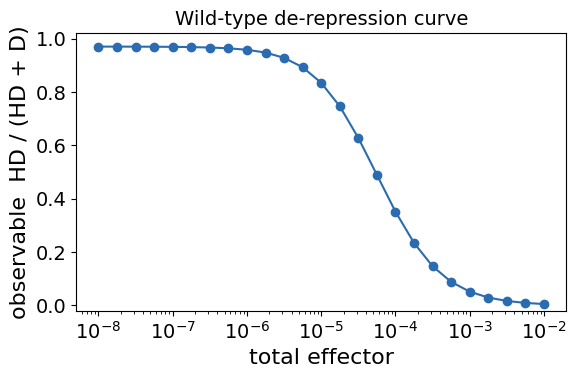

In [2]:
theta_wt = model.observable(effector, genotype="wt")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(effector, theta_wt, "o-", color="#2b6cb0")
ax.set_xlabel("total effector")
ax.set_ylabel("observable  HD / (HD + D)")
ax.set_title("Wild-type de-repression curve")
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()

## 2. What the protein is doing under the hood

`solve_species` returns every free/bound concentration at one effector value, so
we can watch the population shift from operator-bound (HD) to effector-bound (LE)
as the titrant increases.

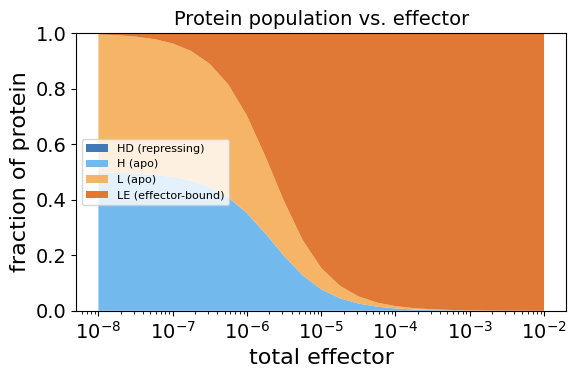

In [3]:
species = [solve_species(*model.genotype_ks("wt"),
                         model.protein_total, model.dna_total, E)
           for E in effector]

frac = {s: np.array([sp[s] for sp in species]) / model.protein_total
        for s in ("HD", "H", "L", "LE")}

fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(effector, frac["HD"], frac["H"], frac["L"], frac["LE"],
             labels=["HD (repressing)", "H (apo)", "L (apo)", "LE (effector-bound)"],
             colors=["#2b6cb0", "#63b3ed", "#f6ad55", "#dd6b20"], alpha=0.9)
ax.set_xscale("log")
ax.set_xlabel("total effector")
ax.set_ylabel("fraction of protein")
ax.set_title("Protein population vs. effector")
ax.set_ylim(0, 1)
ax.legend(loc="center left", fontsize=8)
fig.tight_layout()

## 3. Manual mutations as `ddg` kwargs

For a quick one-off, pass a per-state `ddg` dict straight to `observable`. Each
value is a stability change in kT; omitted states are 0. Watch how perturbing
different states reshapes the curve differently:

- destabilizing **HD** (+kT) weakens repression → the whole curve drops;
- stabilizing **LE** (−kT) makes effector bind more easily → the curve shifts left.

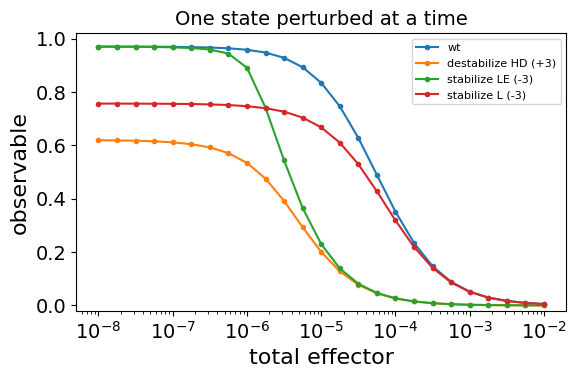

In [4]:
variants = {
    "wt": {},
    "destabilize HD (+3)": {"HD": 3.0},
    "stabilize LE (-3)": {"LE": -3.0},
    "stabilize L (-3)": {"L": -3.0},
}

fig, ax = plt.subplots(figsize=(6, 4))
for label, ddg in variants.items():
    ax.semilogx(effector, model.observable(effector, ddg=ddg), "o-", ms=3, label=label)
ax.set_xlabel("total effector")
ax.set_ylabel("observable")
ax.set_title("One state perturbed at a time")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()

## 4. A named mutation catalog + a titration table

`MutationEffects` holds named mutations and their (optional) in-state pairwise
epistasis. `build_titration_df` then enumerates wt + singles + doubles and emits
the long-form table the analysis tools consume.

> **Naming:** `cat_response` accepts any labels, but `extract_epistasis` requires
> the `XsiteY` convention (e.g. `A1V`, `A2V` → `A1V/A2V`). We use it throughout so
> both tools are happy.

In [5]:
effects = (MutationEffects()
           .add_mutation("A1V", HD=3.0)      # weakens repression
           .add_mutation("A2V", LE=-3.0)     # tightens effector binding
           .add_epistasis("A1V", "A2V"))     # NB: zero thermodynamic epistasis

df = build_titration_df(model, effector, effects=effects,
                        observable_std=0.02)
print("genotypes:", sorted(df['genotype'].unique()))
df.head()

genotypes: ['A1V', 'A1V/A2V', 'A2V', 'wt']


,genotype,titrant_name,titrant_conc,observable,observable_std
0,wt,effector,1.000000e-08,0.970305,0.02
1,wt,effector,1.778279e-08,0.970220,0.02
2,wt,effector,3.162278e-08,0.970070,0.02
3,wt,effector,5.623413e-08,0.969802,0.02
4,wt,effector,1.000000e-07,0.969320,0.02


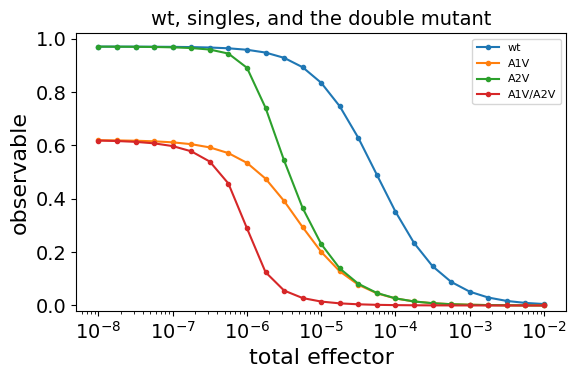

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for geno in enumerate_genotypes(effects.mutations, order=2):
    sub = df[df["genotype"] == geno]
    ax.semilogx(sub["titrant_conc"], sub["observable"], "o-", ms=3, label=geno)
ax.set_xlabel("total effector")
ax.set_ylabel("observable")
ax.set_title("wt, singles, and the double mutant")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()

## 5. Classify each curve with `tfs-cat-response`

Feed the table straight in: `genotype` is the grouping axis, `titrant_conc` is
x, `observable` is y, `observable_std` is the weight.

In [7]:
from tfscreen.analysis.cat_response.cat_response import cat_response

results, predictions, assessment, delta = cat_response(
    df, x_obs="titrant_conc", y_obs="observable", y_std="observable_std",
    progress=False)

results[["genotype", "best_model", "response_class", "omnibus_q"]]

,genotype,best_model,response_class,omnibus_q
0,wt,repressor,real,0.0
1,A1V,repressor,real,0.0
2,A2V,repressor,real,0.0
3,A1V/A2V,repressor,real,0.0


## 6. The punchline: observable epistasis with *no* thermodynamic epistasis

We set `add_epistasis("A1V", "A2V")` with **all-zero** state effects — there is no
thermodynamic interaction between the two mutations. Yet `extract_epistasis`
reports substantial epistasis in the observable, and it **flips sign across the
titration**. That is the pure nonlinearity of $\mathrm{HD}/(\mathrm{HD}+\mathrm{D})$,
not a property of the underlying biophysics — exactly the trap to watch for when
interpreting real epistasis curves.

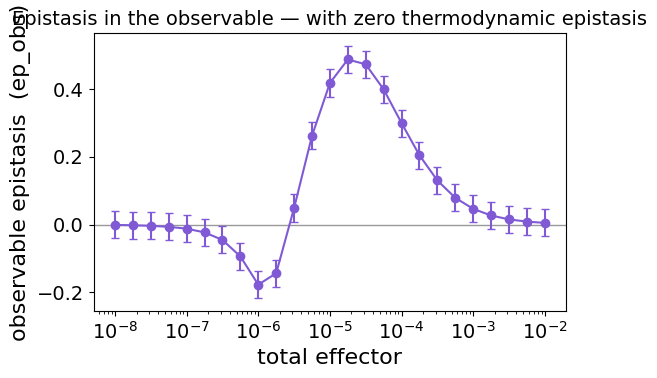

In [8]:
from tfscreen.analysis.extract_epistasis import extract_epistasis

ep = extract_epistasis(df, y_obs="observable", y_std="observable_std",
                       group_by="titrant_conc")

sub = ep[ep["genotype"] == "A1V/A2V"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color="0.6", lw=1)
ax.errorbar(sub["titrant_conc"], sub["ep_obs"], yerr=sub["ep_std"],
            fmt="o-", color="#805ad5", capsize=3)
ax.set_xscale("log")
ax.set_xlabel("total effector")
ax.set_ylabel("observable epistasis  (ep_obs)")
ax.set_title("Epistasis in the observable — with zero thermodynamic epistasis")
fig.tight_layout()

Try flipping on a real interaction — e.g. `.add_epistasis("A1V", "A2V", HD=2.0)` —
and re-running from cell 4. The curve's shape and baseline both change, and you
can start to build intuition for which thermodynamic interactions produce which
observable signatures.

## 7. Random libraries with the sampler

Instead of hand-setting every effect, draw them from per-state Normals. Each
value is either an sd (mean 0) or a `(mean, sd)` tuple. Handy for generating a
library of curves to stress-test the analysis tools.

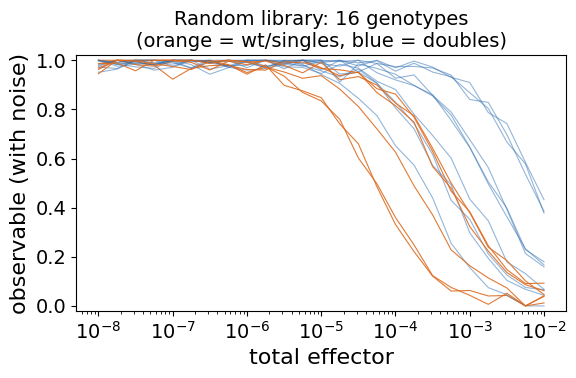

In [9]:
muts = [f"A{i}V" for i in range(1, 6)]   # A1V ... A5V
rng = np.random.default_rng(0)

rand_effects = sample_effects(
    muts,
    effect_sd={"HD": 1.5, "H": 0.5, "L": 0.5, "LE": 1.5},
    epistasis_sd={"HD": 0.3, "LE": 0.3},
    rng=rng,
)

rand_df = build_titration_df(model, effector, effects=rand_effects,
                            observable_std=0.02, noise_sd=0.02, rng=rng)

fig, ax = plt.subplots(figsize=(6, 4))
for geno, sub in rand_df.groupby("genotype"):
    ax.semilogx(sub["titrant_conc"], sub["observable"], "-", lw=0.8,
                color="#2b6cb0" if "/" in geno else "#dd6b20",
                alpha=0.5 if "/" in geno else 0.9)
ax.set_xlabel("total effector")
ax.set_ylabel("observable (with noise)")
ax.set_title(f"Random library: {rand_df['genotype'].nunique()} genotypes\n"
             "(orange = wt/singles, blue = doubles)")
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()

From here you can run `cat_response` / `extract_epistasis` on `rand_df` just as
above, or tune `ln_K_*`, the concentrations, and the effect distributions to
explore how the observable curves — and their apparent epistasis — respond.